# Tugas 1A — Notebook Pertamaku

## Machine Learning & AI

**Nama:** Pandji Fajrian
**NIM:** [2553110010]
**Kelas:** [Bisnis Digital]


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)

X = wine.data
y = wine.target

print("Jumlah data:", X.shape[0])
print("Jumlah fitur:", X.shape[1])
print("Nama kelas:", wine.target_names)

Jumlah data: 178
Jumlah fitur: 13
Nama kelas: ['class_0' 'class_1' 'class_2']


In [49]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [50]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [51]:
y.value_counts()

,count
target,
1,71
0,59
2,48


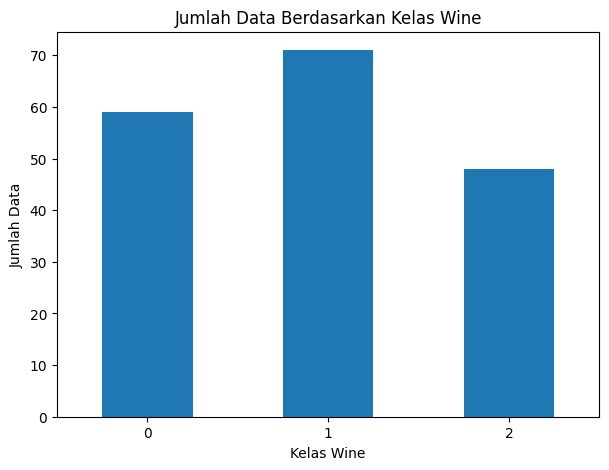

In [52]:
plt.figure(figsize=(7,5))

y.value_counts().sort_index().plot(kind='bar')

plt.title('Jumlah Data Berdasarkan Kelas Wine')
plt.xlabel('Kelas Wine')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)

plt.show()

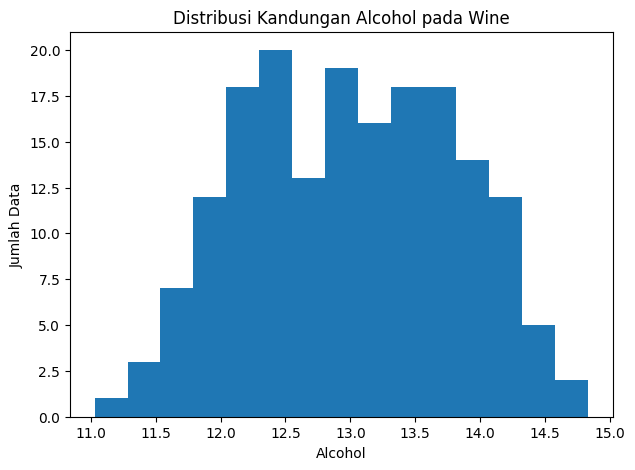

In [53]:
plt.figure(figsize=(7,5))

plt.hist(X['alcohol'], bins=15)

plt.title('Distribusi Kandungan Alcohol pada Wine')
plt.xlabel('Alcohol')
plt.ylabel('Jumlah Data')

plt.show()

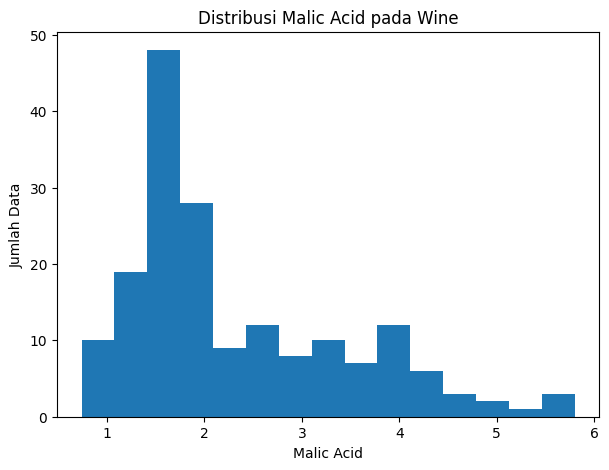

In [54]:
plt.figure(figsize=(7,5))

plt.hist(X['malic_acid'], bins=15)

plt.title('Distribusi Malic Acid pada Wine')
plt.xlabel('Malic Acid')
plt.ylabel('Jumlah Data')

plt.show()

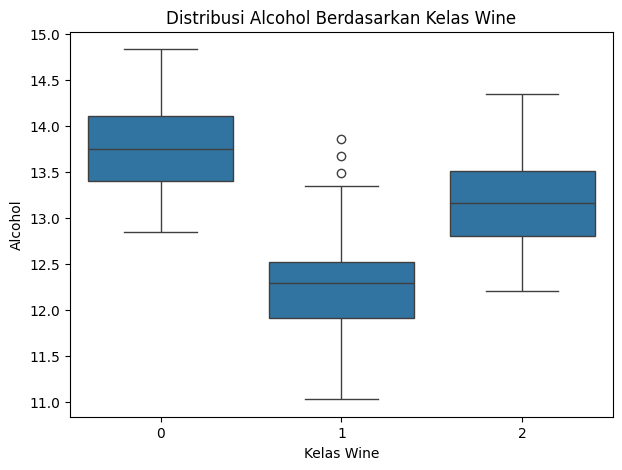

In [55]:
plt.figure(figsize=(7,5))

sns.boxplot(x=y, y=X['alcohol'])

plt.title('Distribusi Alcohol Berdasarkan Kelas Wine')
plt.xlabel('Kelas Wine')
plt.ylabel('Alcohol')

plt.show()

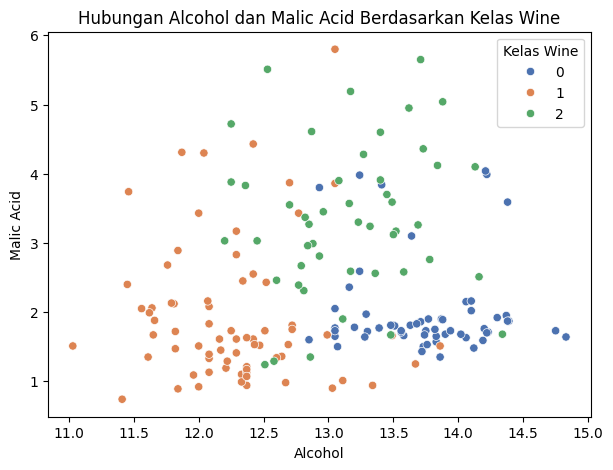

In [56]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X['alcohol'],
    y=X['malic_acid'],
    hue=y,
    palette='deep'
)

plt.title('Hubungan Alcohol dan Malic Acid Berdasarkan Kelas Wine')
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.legend(title='Kelas Wine')

plt.show()

## 2. T / E / P

### Task (T)

Tugas model adalah mengklasifikasikan wine ke dalam kelas yang sesuai berdasarkan karakteristik kimia yang terdapat pada dataset.

### Experience (E)

Pengalaman model berasal dari data training yang berisi fitur-fitur kimia wine beserta label kelasnya.

### Performance (P)

Kinerja model diukur menggunakan classification report pada data testing, terutama melalui precision, recall, f1-score, dan accuracy.


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))

Jumlah data training: 124
Jumlah data testing: 54


In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))
])

print(model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression(max_iter=1000))])


In [59]:
model.fit(X_train, y_train)

print("Model berhasil dilatih.")

Model berhasil dilatih.


In [60]:
y_pred = model.predict(X_test)

print("Hasil prediksi 10 data pertama:")
print(y_pred[:10])

Hasil prediksi 10 data pertama:
[0 1 0 0 0 0 2 1 1 2]


In [61]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=wine.target_names
))

              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



## 3. Analisis Hasil

Berdasarkan classification report, model memperoleh accuracy sebesar **98%** pada 54 data testing. Nilai precision, recall, dan f1-score secara keseluruhan juga berada di sekitar **98%**, sehingga model mampu mengklasifikasikan data wine dengan sangat baik.

Pada class_0, precision sebesar 0,95 dan recall sebesar 1,00. Pada class_1, precision sebesar 1,00 dan recall sebesar 0,95. Sementara itu, class_2 memperoleh precision, recall, dan f1-score sebesar 1,00.

Hasil tersebut menunjukkan bahwa hanya terdapat sedikit kesalahan klasifikasi pada data testing. Namun, hasil yang tinggi pada data testing belum tentu menjamin model akan selalu memiliki performa yang sama pada data baru.


## 4. Kesimpulan

Berdasarkan proses yang dilakukan, Wine Dataset dapat digunakan untuk membangun model klasifikasi menggunakan machine learning. Tahapan yang dilakukan meliputi eksplorasi data, visualisasi, pembagian data menjadi training dan testing, pembuatan model, training, prediksi, dan evaluasi.

Model yang digunakan memperoleh accuracy sebesar **98%** pada 54 data testing. Hasil ini menunjukkan bahwa model mampu mengklasifikasikan data wine dengan performa yang sangat baik. Namun, model tetap perlu diuji menggunakan data baru untuk memastikan kemampuannya dalam melakukan generalisasi.


## 5. Sumber

Dataset yang digunakan adalah **Wine Recognition Dataset** dari Scikit-learn.
